## GPU Use

In [1]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [2]:
import tensorflow as tf
import timeit

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print(
      '\n\nThis error most likely means that this notebook is not '
      'configured to use a GPU.  Change this in Notebook Settings via the '
      'command palette (cmd/ctrl-shift-P) or the Edit menu.\n\n')
  raise SystemError('GPU device not found')

def cpu():
  with tf.device('/cpu:0'):
    random_image_cpu = tf.random.normal((100, 100, 100, 3))
    net_cpu = tf.keras.layers.Conv2D(32, 7)(random_image_cpu)
    return tf.math.reduce_sum(net_cpu)

def gpu():
  with tf.device('/device:GPU:0'):
    random_image_gpu = tf.random.normal((100, 100, 100, 3))
    net_gpu = tf.keras.layers.Conv2D(32, 7)(random_image_gpu)
    return tf.math.reduce_sum(net_gpu)

# We run each op once to warm up; see: https://stackoverflow.com/a/45067900
cpu()
gpu()

# Run the op several times.
print('Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images '
      '(batch x height x width x channel). Sum of ten runs.')
print('CPU (s):')
cpu_time = timeit.timeit('cpu()', number=10, setup="from __main__ import cpu")
print(cpu_time)
print('GPU (s):')
gpu_time = timeit.timeit('gpu()', number=10, setup="from __main__ import gpu")
print(gpu_time)
print('GPU speedup over CPU: {}x'.format(int(cpu_time/gpu_time)))

Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images (batch x height x width x channel). Sum of ten runs.
CPU (s):
0.1810430790000055
GPU (s):
0.056791078999992806
GPU speedup over CPU: 3x


In [3]:
# If running on Colab, uncomment the next line
%tensorflow_version 2.x

device_name = tf.test.gpu_device_name()
print('GPU not found.') if device_name != '/device:GPU:0' else print('Found GPU at: {}'.format(device_name))

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
Found GPU at: /device:GPU:0


# 데이터 전처리

### 데이터 불러오기
-> 데이터셋 구축

In [4]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
base_path = '/content/drive/MyDrive/DS팀 데이터 저장소'

def collect_image_data(root_path):
    data_list = []

    # 각 폴더별 라벨링
    configs = [
        {
            'sub_path': 'Oral Images Dataset/original_data/malignant_lesions',
            'label': 1
        },
        {
            'sub_path': 'Oral Images Dataset/original_data/benign_lesions',
            'label': 0
        },
        {
            'sub_path': 'Oral Cancer Images for Classification/Oral Cancer photos',
            'label': 1
        },
        {
            'sub_path': 'Oral Cancer Images for Classification/normal',
            'label': 0
        },
        {
            'sub_path': 'ORAL CANCER DATASET/Oral Cancer/Oral Cancer Dataset/CANCER',
            'label': 1
        },
        {
            'sub_path': 'ORAL CANCER DATASET/Oral Cancer/Oral Cancer Dataset/NON CANCER',
            'label': 0
        }
    ]

    for config in configs:
        folder_path = os.path.join(root_path, config['sub_path'])

        if os.path.exists(folder_path):
            files = os.listdir(folder_path)
            for f in files:
                # 이미지 파일 확장자 체크 (jpg, png 등)
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                    img_path = os.path.join(folder_path, f)
                    data_list.append({
                        'file_path': img_path,
                        'file_name': f,
                        'label': config['label'],
                        'source': config['sub_path'].split('/')[0]
                    })
        else:
            print(f"경로를 찾을 수 없습니다: {folder_path}")

    return pd.DataFrame(data_list)

# 데이터 수집 실행
df = collect_image_data(base_path)

# 결과 확인
print(f"총 수집된 이미지 수: {len(df)}")
print(df['label'].value_counts()) # 라벨별 데이터 분포 확인
display(df.head())

# CSV로 저장
df.to_csv('oral_cancer_dataset_table.csv', index=False)

총 수집된 이미지 수: 2306
label
1    1340
0     966
Name: count, dtype: int64


,file_path,file_name,label,source
0,/content/drive/MyDrive/DS팀 데이터 저장소/Or...,80.jpg,1,Oral Images Dataset
1,/content/drive/MyDrive/DS팀 데이터 저장소/Or...,67.jpg,1,Oral Images Dataset
2,/content/drive/MyDrive/DS팀 데이터 저장소/Or...,27.jpg,1,Oral Images Dataset
3,/content/drive/MyDrive/DS팀 데이터 저장소/Or...,73.jpg,1,Oral Images Dataset
4,/content/drive/MyDrive/DS팀 데이터 저장소/Or...,18.jpg,1,Oral Images Dataset


### Train / Test 분할
-> 원본 0, 1 비율 유지

In [6]:
from sklearn.model_selection import train_test_split

# Train(80%) / Temp(20%) 분할
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Temp -> Val(10%) / Test(10%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['label']
)

print(f"Train set: {len(train_df)} | Val set: {len(val_df)} | Test set: {len(test_df)}")

Train set: 1844 | Val set: 231 | Test set: 231


### Resize 및 정규화

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class OralDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['file_path']
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx]['label']

        if self.transform:
            image = self.transform(image)
        return image, label

# 전처리 파이프라인 설정
# Resize(224x224) + 정규화(Normalization)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # 데이터 증강: 불균형 해결 도움
    transforms.RandomRotation(10),     # 데이터 증강
    transforms.ToTensor(),
    transforms.Normalize(mean, std)    # 정규화
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# DataLoader 생성
train_loader = DataLoader(OralDataset(train_df, train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(OralDataset(val_df, val_test_transform), batch_size=32)
test_loader = DataLoader(OralDataset(test_df, val_test_transform), batch_size=32)

### 클래스 불균형 처리

In [8]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 클래스 가중치 계산
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = torch.tensor(weights, dtype=torch.float)

print(f"Computed Class Weights: {class_weights}")

Computed Class Weights: tensor([1.1943, 0.8601])


### 데이터 품질 확인
-> 모델 노이즈 감소

In [9]:
import cv2
import numpy as np

def check_image_quality(img_path):
    img = cv2.imread(img_path)
    if img is None: return None

    # 밝기 평균 계산
    brightness = np.mean(img)
    # 선명도 계산 - Laplacian 분산
    sharpness = cv2.Laplacian(img, cv2.CV_64F).var()

    return brightness, sharpness

# 데이터프레임에 적용하여 시각화 가능
# df['brightness'], df['sharpness'] = zip(*df['file_path'].apply(check_image_quality))

In [10]:
# 상위 5개 데이터에 대해 밝기와 선명도 수치 출력
print(f"{'파일명':<15} | {'밝기(Brightness)':<18} | {'선명도(Sharpness)':<18}")
print("-" * 55)

for i in range(5):
    path = df.iloc[i]['file_path']
    name = df.iloc[i]['file_name']

    res = check_image_quality(path)

    if res:
        b, s = res
        print(f"{name:<15} | {b:<18.2f} | {s:<18.2f}")
    else:
        print(f"{name:<15} | 파일을 찾을 수 없습니다.")

파일명             | 밝기(Brightness)     | 선명도(Sharpness)    
-------------------------------------------------------
80.jpg          | 114.39             | 82.62             
67.jpg          | 128.57             | 117.11            
27.jpg          | 122.64             | 44.34             
73.jpg          | 64.31              | 56.98             
18.jpg          | 113.93             | 30.56             


### K-Fold 교차검증

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader

# K-Fold 설정
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42) #각 Fold 별로 악성 양성 비율 일정하게

# 전체 데이터셋을 보관할 리스트
fold_results = []


for fold, (train_idx, val_idx) in enumerate(skf.split(df['file_path'], df['label'])):
    print(f"\n--- Fold {fold+1} / {K} 학습 시작 ---")

    # Fold의 학습/검증 데이터 생성
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    # 앞서 만든 OralDataset 클래스와 전처리(transform) 적용
    train_dataset = OralDataset(train_df, transform=train_transform)
    val_dataset = OralDataset(val_df, transform=val_test_transform)

    # DataLoader
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    print(f"학습 데이터: {len(train_df)}개, 검증 데이터: {len(val_df)}개")

    # ---------------------------------------------------------
    # 여기에 모델 정의 및 학습 코드
    # ex) model = MyModel().to(device)
    #     train_model(model, train_loader, val_loader)
    # ---------------------------------------------------------

    # Fold별 최종 검증 성능을 기록 -> 평균내기
    # fold_results.append(val_accuracy)


--- Fold 1 / 5 학습 시작 ---
학습 데이터: 1844개, 검증 데이터: 462개

--- Fold 2 / 5 학습 시작 ---
학습 데이터: 1845개, 검증 데이터: 461개

--- Fold 3 / 5 학습 시작 ---
학습 데이터: 1845개, 검증 데이터: 461개

--- Fold 4 / 5 학습 시작 ---
학습 데이터: 1845개, 검증 데이터: 461개

--- Fold 5 / 5 학습 시작 ---
학습 데이터: 1845개, 검증 데이터: 461개


## 데이터 요약

In [12]:
def generate_data_report(train, val, test):
    report = pd.DataFrame({
        'Dataset': ['Train', 'Validation', 'Test'],
        'Total': [len(train), len(val), len(test)],
        'Malignant(1)': [len(train[train['label']==1]), len(val[val['label']==1]), len(test[test['label']==1])],
        'Benign(0)': [len(train[train['label']==0]), len(val[val['label']==0]), len(test[test['label']==0])],
        'Cancer_Ratio(%)': [
            (train['label']==1).mean()*100,
            (val['label']==1).mean()*100,
            (test['label']==1).mean()*100
        ]
    })
    return report

report_df = generate_data_report(train_df, val_df, test_df)
display(report_df)

,Dataset,Total,Malignant(1),Benign(0),Cancer_Ratio(%)
0,Train,1845,1072,773,58.102981
1,Validation,461,268,193,58.134490
2,Test,231,134,97,58.008658


In [13]:
# K-Fold 이후 데이터 요약

import pandas as pd
import numpy as np

def generate_kfold_summary(df, n_splits=5):
    summary_list = []

    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    # 전체 데이터 통계
    total_len = len(df)
    total_c1 = (df['label'] == 1).sum()
    total_c0 = (df['label'] == 0).sum()

    print(f"=== [전체 데이터 요약] ===")
    print(f"총 이미지 수: {total_len}")
    print(f"Malignant (1): {total_c1} ({total_c1/total_len*100:.1f}%)")
    print(f"Benign (0): {total_c0} ({total_c0/total_len*100:.1f}%)\n")

    # Fold별 통계 계산
    for fold, (train_idx, val_idx) in enumerate(skf.split(df['file_path'], df['label'])):
        train_df = df.iloc[train_idx]
        val_df = df.iloc[val_idx]

        summary_list.append({
            'Fold': fold + 1,
            'Train_Total': len(train_df),
            'Train_Malignant(1)': (train_df['label'] == 1).sum(),
            'Train_Benign(0)': (train_df['label'] == 0).sum(),
            'Val_Total': len(val_df),
            'Val_Malignant(1)': (val_df['label'] == 1).sum(),
            'Val_Benign(0)': (val_df['label'] == 0).sum(),
            'Val_Cancer_Ratio(%)': round((val_df['label'] == 1).mean() * 100, 2)
        })

    report_df = pd.DataFrame(summary_list)
    return report_df

kfold_report = generate_kfold_summary(df, n_splits=5)
display(kfold_report)

=== [전체 데이터 요약] ===
총 이미지 수: 2306
Malignant (1): 1340 (58.1%)
Benign (0): 966 (41.9%)



,Fold,Train_Total,Train_Malignant(1),Train_Benign(0),Val_Total,Val_Malignant(1),Val_Benign(0),Val_Cancer_Ratio(%)
0,1,1844,1072,772,462,268,194,58.01
1,2,1845,1072,773,461,268,193,58.13
2,3,1845,1072,773,461,268,193,58.13
3,4,1845,1072,773,461,268,193,58.13
4,5,1845,1072,773,461,268,193,58.13


데이터 예시

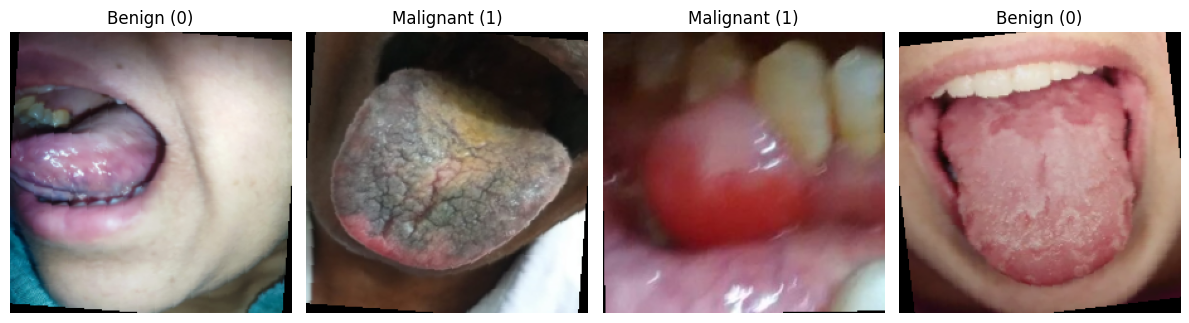

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 시각화를 위한 역정규화 함수
def imshow(img, title=None):
    # 정규화된 텐서를 넘파이 배열로 변환
    img = img.numpy().transpose((1, 2, 0))

    # 설정하신 mean, std 값으로 역정규화
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1) # 이미지 범위를 0~1 사이로 제한

    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# train_loader에서 첫 번째 배치를 가져옴
images, labels = next(iter(train_loader))

# 여러 개의 이미지 시각화 (예: 4개)
plt.figure(figsize=(12, 6))
class_names = {0: 'Benign (0)', 1: 'Malignant (1)'}

for i in range(4):
    plt.subplot(1, 4, i + 1)
    imshow(images[i], title=class_names[labels[i].item()])

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# DataLoader -> 데이터를 Numpy 배열로 변환
def convert_to_numpy(loader):
    x_list, y_list = [], []
    for imgs, lbs in loader:
        # PyTorch(NCHW) -> TensorFlow(NHWC) 차원 변경
        imgs = imgs.permute(0, 2, 3, 1).numpy()
        x_list.append(imgs)
        y_list.append(lbs.numpy())
    return np.concatenate(x_list, axis=0), np.concatenate(y_list, axis=0)

X_train_np, y_train_np = convert_to_numpy(train_loader)
X_val_np, y_val_np = convert_to_numpy(test_loader)

# 하드드라이브(파일)로 저장
np.save('X_train.npy', X_train_np)
np.save('y_train.npy', y_train_np)
np.save('X_val.npy', X_val_np)
np.save('y_val.npy', y_val_np)

print("파일 저장 완료")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


파일 저장 완료: X_train.npy, y_train.npy 등 4개 파일
